# Sound 02: Liberal vs Conservative Comparison

**Question:** Do liberal and conservative belief networks genuinely differ?

The baseline found liberals have a denser network (368 vs 291 edges), but this may be
a sample size artifact (17,604 liberals vs 21,122 conservatives interact differently
with regularization). This notebook fixes that with:

1. **Sample-size matching** — Downsample conservatives to match liberal N
2. **Permutation test** — Is the lib/con difference larger than random splits?
3. **Bootstrap CIs** — Which specific edges genuinely differ?
4. **Density comparison** — Re-check with matched samples
5. **Community comparison** — Do belief clusters reorganize?

**Period:** 2000–2010, regularized partial Pearson (alpha=0.2)

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from tqdm.auto import tqdm

from src.loaders.clean_raw_data import clean_datasets
from src.generators.corr_make_network import (
    calculate_correlation_matrix, CorrelationMethod, EdgeSuppressionMethod
)
from src.generators.corr_make_conditioned_network import calculate_conditioned_correlation_matrix
from src.analyzers.matrix_compare import compare_matrices
from src.analyzers.triad_analyzer import count_triads
from src.visualizers.network_visualizer import calculate_network_stats

C:\Users\timbo\miniconda3\Lib\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.0.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [2]:
cleaned_df = clean_datasets()

YEARS = list(range(2000, 2011, 2))
METHOD = CorrelationMethod.PEARSON
EDGE_SUPP = EdgeSuppressionMethod.REGULARIZATION
SUPP_PARAMS = {'regularization': 0.2}

print(f"Reference period: {YEARS}")

Loading dataset from from cache...


Done! ✨


Reference period: [2000, 2002, 2004, 2006, 2008, 2010]


## 2.1 Build Matched Networks

The core fix: downsample conservatives to match liberal sample size,
so regularization behaves identically for both groups.

In [3]:
# Filter to 2000-2010 respondents with non-null POLVIEWS
df_period = cleaned_df[cleaned_df['YEAR'].isin(YEARS)].copy()
df_polviews = df_period[df_period['POLVIEWS'].notna()].copy()

df_liberal = df_polviews[df_polviews['POLVIEWS'] < 0]
df_conservative = df_polviews[df_polviews['POLVIEWS'] > 0]
df_moderate = df_polviews[df_polviews['POLVIEWS'] == 0]

N_lib = len(df_liberal)
N_con = len(df_conservative)
N_mod = len(df_moderate)

print(f"2000-2010 respondents with POLVIEWS:")
print(f"  Liberal (POLVIEWS < 0):      {N_lib}")
print(f"  Moderate (POLVIEWS = 0):     {N_mod}")
print(f"  Conservative (POLVIEWS > 0): {N_con}")
print(f"  Total:                       {N_lib + N_mod + N_con}")
print(f"\nDownsampling conservatives from {N_con} to {N_lib} (matching liberal N)")

2000-2010 respondents with POLVIEWS:
  Liberal (POLVIEWS < 0):      3645
  Moderate (POLVIEWS = 0):     5242
  Conservative (POLVIEWS > 0): 4636
  Total:                       13523

Downsampling conservatives from 4636 to 3645 (matching liberal N)


In [4]:
# Build liberal network (full sample)
corr_liberal, df_lib_used = calculate_conditioned_correlation_matrix(
    cleaned_df, years_of_interest=YEARS,
    method=METHOD, partial=True,
    edge_suppression=EDGE_SUPP, suppression_params=SUPP_PARAMS,
    variable_to_condition='POLVIEWS', condition='less_than_zero',
    return_df=True, verbose=True
)

print(f"\nLiberal network: {corr_liberal.shape[0]} variables, "
      f"{(np.abs(corr_liberal.values) > 0).sum() // 2} edges")


CONDITIONING INFORMATION
Conditioning variable: POLVIEWS
Condition: less_than_zero
Filtered samples count: 17604 of 72390 (24.3%)
--------------------------------------------------

CORRELATION NETWORK STATISTICS
Variables filtered out (metadata): 3
Variables included in analysis: 133
Total number of samples: 3645
--------------------------------------------------


Variables removed due to NaN correlations: 13
Remaining variables after NaN filtering: 120
Removed variables (first 10): NATARMS, NATAID, NATDRUG, NATCITY, NATSPAC, NATRACE, NATCRIME, NATENVIR, MARHOMO, NATHEAL...
--------------------------------------------------


Sample size statistics for correlations:
  Mean: 7005.4
  Min: 823
  Max: 17604

Liberal network: 120 variables, 405 edges


In [5]:
# Build MATCHED conservative network (downsampled to N_lib)
df_con_matched = df_conservative.sample(n=N_lib, random_state=42)

# We need to pass the full dataframe structure but with only the matched rows.
# Since calculate_correlation_matrix expects the full df with YEAR column,
# we pass the pre-filtered dataframe directly.
corr_con_matched = calculate_correlation_matrix(
    df_con_matched,
    method=METHOD, partial=True,
    edge_suppression=EDGE_SUPP, suppression_params=SUPP_PARAMS,
    verbose=True
)

print(f"\nMatched conservative network: {corr_con_matched.shape[0]} variables, "
      f"{(np.abs(corr_con_matched.values) > 0).sum() // 2} edges")


CORRELATION NETWORK STATISTICS
Variables filtered out (metadata): 3
Variables included in analysis: 133
Total number of samples: 3645
--------------------------------------------------
Variables removed due to NaN correlations: 15
Remaining variables after NaN filtering: 118
Removed variables (first 10): NATARMS, NATAID, NATDRUG, NATCITY, NATSPAC, NATRACE, NATCRIME, NATENVIR, MARHOMO, NATHEAL...
--------------------------------------------------


Sample size statistics for correlations:
  Mean: 1518.5
  Min: 152
  Max: 3645

Matched conservative network: 118 variables, 356 edges


In [6]:
# Also build full-sample conservative network for reference
corr_con_full = calculate_conditioned_correlation_matrix(
    cleaned_df, years_of_interest=YEARS,
    method=METHOD, partial=True,
    edge_suppression=EDGE_SUPP, suppression_params=SUPP_PARAMS,
    variable_to_condition='POLVIEWS', condition='greater_than_zero',
    verbose=True
)

print(f"\nFull conservative network: {corr_con_full.shape[0]} variables, "
      f"{(np.abs(corr_con_full.values) > 0).sum() // 2} edges")

print(f"\n=== Summary ===")
print(f"Liberal (N={N_lib}):               {corr_liberal.shape[0]} vars, "
      f"{(np.abs(corr_liberal.values) > 0).sum() // 2} edges")
print(f"Conservative matched (N={N_lib}):  {corr_con_matched.shape[0]} vars, "
      f"{(np.abs(corr_con_matched.values) > 0).sum() // 2} edges")
print(f"Conservative full (N={N_con}):     {corr_con_full.shape[0]} vars, "
      f"{(np.abs(corr_con_full.values) > 0).sum() // 2} edges")


CONDITIONING INFORMATION
Conditioning variable: POLVIEWS
Condition: greater_than_zero
Filtered samples count: 21122 of 72390 (29.2%)
--------------------------------------------------

CORRELATION NETWORK STATISTICS
Variables filtered out (metadata): 3
Variables included in analysis: 133
Total number of samples: 4636
--------------------------------------------------


Variables removed due to NaN correlations: 14
Remaining variables after NaN filtering: 119
Removed variables (first 10): NATARMS, NATAID, NATDRUG, NATCITY, NATSPAC, NATRACE, NATCRIME, NATENVIR, MARHOMO, NATHEAL...
--------------------------------------------------


Sample size statistics for correlations:
  Mean: 8424.3
  Min: 817
  Max: 21122

Full conservative network: 119 variables, 349 edges

=== Summary ===
Liberal (N=3645):               120 vars, 405 edges
Conservative matched (N=3645):  118 vars, 356 edges
Conservative full (N=4636):     119 vars, 349 edges


## 2.2 Permutation Test for Global Structure

**Question:** Is the difference between liberal and conservative networks larger than
you'd expect by randomly splitting respondents?

We shuffle lib/con labels 200 times, keeping group sizes fixed, and compare
the observed Euclidean distance between correlation matrices to the null distribution.

In [7]:
# Observed distance (using matched conservative network)
# Align to common variables
common_vars = sorted(set(corr_liberal.columns) & set(corr_con_matched.columns))
lib_aligned = corr_liberal.loc[common_vars, common_vars]
con_aligned = corr_con_matched.loc[common_vars, common_vars]

# Euclidean distance on upper triangle
triu_mask = np.triu(np.ones(len(common_vars), dtype=bool), k=1)
lib_upper = lib_aligned.values[triu_mask]
con_upper = con_aligned.values[triu_mask]
observed_distance = np.sqrt(np.sum((lib_upper - con_upper)**2))

print(f"Common variables: {len(common_vars)}")
print(f"Observed Euclidean distance (lib vs con matched): {observed_distance:.4f}")

Common variables: 118
Observed Euclidean distance (lib vs con matched): 0.8902


In [8]:
%%time

# Permutation test: shuffle lib/con labels
N_PERMS = 200

# Pool all respondents with non-null, non-zero POLVIEWS in 2000-2010
df_pool = pd.concat([df_liberal, df_conservative]).copy()
n_total = len(df_pool)

print(f"Pooled sample: {n_total} respondents")
print(f"Split sizes: {N_lib} (liberal) vs {n_total - N_lib} (conservative)")
print(f"Running {N_PERMS} permutations...")

rng = np.random.default_rng(42)
null_distances = []

for i in tqdm(range(N_PERMS), desc='Permutation test'):
    # Randomly split into two groups of size N_lib and N_con
    shuffled_idx = rng.permutation(n_total)
    group_a_idx = shuffled_idx[:N_lib]
    group_b_idx = shuffled_idx[N_lib:N_lib + N_lib]  # match size
    
    df_a = df_pool.iloc[group_a_idx]
    df_b = df_pool.iloc[group_b_idx]
    
    try:
        corr_a = calculate_correlation_matrix(
            df_a, method=METHOD, partial=True,
            edge_suppression=EDGE_SUPP, suppression_params=SUPP_PARAMS,
            verbose=False
        )
        corr_b = calculate_correlation_matrix(
            df_b, method=METHOD, partial=True,
            edge_suppression=EDGE_SUPP, suppression_params=SUPP_PARAMS,
            verbose=False
        )
        
        # Align to common variables
        common = sorted(set(corr_a.columns) & set(corr_b.columns))
        if len(common) < 10:
            continue
        a_vals = corr_a.loc[common, common].values
        b_vals = corr_b.loc[common, common].values
        mask = np.triu(np.ones(len(common), dtype=bool), k=1)
        dist = np.sqrt(np.sum((a_vals[mask] - b_vals[mask])**2))
        null_distances.append(dist)
    except Exception:
        continue  # skip failed iterations

null_distances = np.array(null_distances)
print(f"\nCompleted {len(null_distances)} / {N_PERMS} permutations")
print(f"Null distribution: mean={null_distances.mean():.4f}, "
      f"std={null_distances.std():.4f}")

Pooled sample: 8281 respondents
Split sizes: 3645 (liberal) vs 4636 (conservative)
Running 200 permutations...


Permutation test:   0%|          | 0/200 [00:00<?, ?it/s]


Completed 200 / 200 permutations
Null distribution: mean=0.6249, std=0.0390
CPU times: total: 6min 3s
Wall time: 2min 42s


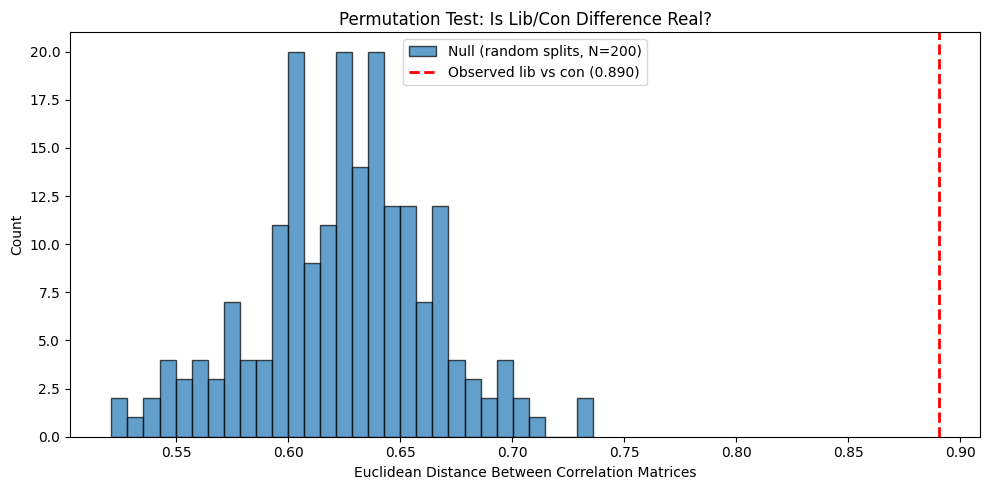

Observed distance:  0.8902
Null mean:          0.6249
Null std:           0.0390
Z-score:            6.81
p-value (one-sided): 0.0000

=> The lib/con network difference is STATISTICALLY SIGNIFICANT.
   The two groups genuinely organize their beliefs differently,
   not just by random sampling variation.


In [9]:
# Compute p-value and visualize
p_value = (null_distances >= observed_distance).mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(null_distances, bins=30, alpha=0.7, edgecolor='black',
        label=f'Null (random splits, N={len(null_distances)})')
ax.axvline(observed_distance, color='red', linewidth=2, linestyle='--',
           label=f'Observed lib vs con ({observed_distance:.3f})')
ax.set_xlabel('Euclidean Distance Between Correlation Matrices')
ax.set_ylabel('Count')
ax.set_title('Permutation Test: Is Lib/Con Difference Real?')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Observed distance:  {observed_distance:.4f}")
print(f"Null mean:          {null_distances.mean():.4f}")
print(f"Null std:           {null_distances.std():.4f}")
print(f"Z-score:            {(observed_distance - null_distances.mean()) / null_distances.std():.2f}")
print(f"p-value (one-sided): {p_value:.4f}")

if p_value < 0.05:
    print("\n=> The lib/con network difference is STATISTICALLY SIGNIFICANT.")
    print("   The two groups genuinely organize their beliefs differently,")
    print("   not just by random sampling variation.")
else:
    print("\n=> The lib/con difference is NOT statistically significant.")
    print("   Random splits of equal size produce similar or larger differences.")

## 2.3 Edge-Level Comparison with Bootstrap Confidence Intervals

Which specific edges genuinely differ between liberal and conservative networks?
We bootstrap 200 iterations to get 95% CIs on the edge-weight differences.

In [10]:
%%time

N_BOOT = 200

# Use the period-filtered dataframes
df_lib_period = df_liberal.copy()
df_con_period = df_conservative.copy()

print(f"Bootstrap: {N_BOOT} iterations")
print(f"Liberal N={len(df_lib_period)}, Conservative N={len(df_con_period)}")

# We'll store edge differences for common variables
# First, determine common variables from full networks
boot_common_vars = sorted(set(corr_liberal.columns) & set(corr_con_matched.columns))
n_vars = len(boot_common_vars)
n_edges = n_vars * (n_vars - 1) // 2

boot_diffs = np.full((N_BOOT, n_edges), np.nan)

rng = np.random.default_rng(123)

for i in tqdm(range(N_BOOT), desc='Bootstrap'):
    # Resample with replacement
    lib_sample = df_lib_period.sample(n=len(df_lib_period), replace=True, random_state=rng.integers(1e9))
    con_sample = df_con_period.sample(n=len(df_lib_period), replace=True, random_state=rng.integers(1e9))
    
    try:
        corr_lib_b = calculate_correlation_matrix(
            lib_sample, method=METHOD, partial=True,
            edge_suppression=EDGE_SUPP, suppression_params=SUPP_PARAMS,
            verbose=False
        )
        corr_con_b = calculate_correlation_matrix(
            con_sample, method=METHOD, partial=True,
            edge_suppression=EDGE_SUPP, suppression_params=SUPP_PARAMS,
            verbose=False
        )
        
        # Align to common vars
        common_b = sorted(set(corr_lib_b.columns) & set(corr_con_b.columns) & set(boot_common_vars))
        if len(common_b) < len(boot_common_vars) * 0.5:
            continue
        
        lib_vals = corr_lib_b.reindex(index=boot_common_vars, columns=boot_common_vars, fill_value=0).values
        con_vals = corr_con_b.reindex(index=boot_common_vars, columns=boot_common_vars, fill_value=0).values
        
        mask = np.triu(np.ones(n_vars, dtype=bool), k=1)
        boot_diffs[i] = lib_vals[mask] - con_vals[mask]
    except Exception:
        continue

# Remove failed iterations
valid_mask = ~np.all(np.isnan(boot_diffs), axis=1)
boot_diffs_valid = boot_diffs[valid_mask]
print(f"\nCompleted {valid_mask.sum()} / {N_BOOT} bootstrap iterations")

Bootstrap: 200 iterations
Liberal N=3645, Conservative N=4636


Bootstrap:   0%|          | 0/200 [00:00<?, ?it/s]

C:\Users\timbo\miniconda3\Lib\site-packages\sklearn\covariance\_graph_lasso.py:131: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: nan, tolerance: 0.0001880032983598644
  coefs, _, _, _ = cd_fast.enet_coordinate_descent_gram(
C:\Users\timbo\miniconda3\Lib\site-packages\sklearn\covariance\_graph_lasso.py:131: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: nan, tolerance: 0.0001417398120593988
  coefs, _, _, _ = cd_fast.enet_coordinate_descent_gram(
C:\Users\timbo\miniconda3\Lib\site-packages\sklearn\covariance\_graph_lasso.py:131: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: nan, tolerance: 8.948675846964912e-05
  coefs, _, _, _ = cd_fast.enet_coordinate_descent_gram(
C:\Users\timbo\miniconda3\Lib\site-packages\sklearn\covariance\_graph_lasso.py:131: ConvergenceWarning: Objective did not

Failed to calculate partial correlations: Non SPD result: the system is too ill-conditioned for this solver. The system is too ill-conditioned for this solver


C:\Users\timbo\miniconda3\Lib\site-packages\sklearn\covariance\_graph_lasso.py:131: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: nan, tolerance: 0.0002846999672633633
  coefs, _, _, _ = cd_fast.enet_coordinate_descent_gram(
C:\Users\timbo\miniconda3\Lib\site-packages\sklearn\covariance\_graph_lasso.py:131: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: nan, tolerance: 0.00026242273193900306
  coefs, _, _, _ = cd_fast.enet_coordinate_descent_gram(
C:\Users\timbo\miniconda3\Lib\site-packages\sklearn\covariance\_graph_lasso.py:131: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: nan, tolerance: 0.00010666455899899967
  coefs, _, _, _ = cd_fast.enet_coordinate_descent_gram(
C:\Users\timbo\miniconda3\Lib\site-packages\sklearn\covariance\_graph_lasso.py:131: ConvergenceWarning: Objective did n

...

C:\Users\timbo\miniconda3\Lib\site-packages\sklearn\covariance\_graph_lasso.py:131: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: nan, tolerance: 7.04195881373992e-05
  coefs, _, _, _ = cd_fast.enet_coordinate_descent_gram(
C:\Users\timbo\miniconda3\Lib\site-packages\sklearn\covariance\_graph_lasso.py:131: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: nan, tolerance: 0.00010924677562052026
  coefs, _, _, _ = cd_fast.enet_coordinate_descent_gram(
C:\Users\timbo\miniconda3\Lib\site-packages\sklearn\covariance\_graph_lasso.py:131: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: nan, tolerance: 0.00029328517206640394
  coefs, _, _, _ = cd_fast.enet_coordinate_descent_gram(
C:\Users\timbo\miniconda3\Lib\site-packages\sklearn\covariance\_graph_lasso.py:131: ConvergenceWarning: Objective did no

Failed to calculate partial correlations: Non SPD result: the system is too ill-conditioned for this solver. The system is too ill-conditioned for this solver


C:\Users\timbo\miniconda3\Lib\site-packages\sklearn\covariance\_graph_lasso.py:131: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: nan, tolerance: 0.00039984964754584206
  coefs, _, _, _ = cd_fast.enet_coordinate_descent_gram(
C:\Users\timbo\miniconda3\Lib\site-packages\sklearn\covariance\_graph_lasso.py:131: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: nan, tolerance: 8.95703751006679e-05
  coefs, _, _, _ = cd_fast.enet_coordinate_descent_gram(
C:\Users\timbo\miniconda3\Lib\site-packages\sklearn\covariance\_graph_lasso.py:131: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: nan, tolerance: 0.0003502164949985943
  coefs, _, _, _ = cd_fast.enet_coordinate_descent_gram(
C:\Users\timbo\miniconda3\Lib\site-packages\sklearn\covariance\_graph_lasso.py:131: ConvergenceWarning: Objective did not

Failed to calculate partial correlations: The system is too ill-conditioned for this solver. The system is too ill-conditioned for this solver



Completed 189 / 200 bootstrap iterations
CPU times: total: 8min 50s
Wall time: 2min 47s


In [11]:
# Compute 95% CIs for each edge
mean_diff = np.nanmean(boot_diffs_valid, axis=0)
ci_lower = np.nanpercentile(boot_diffs_valid, 2.5, axis=0)
ci_upper = np.nanpercentile(boot_diffs_valid, 97.5, axis=0)

# Build edge labels
edge_labels = []
for i in range(n_vars):
    for j in range(i+1, n_vars):
        edge_labels.append((boot_common_vars[i], boot_common_vars[j]))

# Find edges where CI excludes zero
sig_stronger_lib = []  # CI entirely > 0 (liberal edge is stronger)
sig_stronger_con = []  # CI entirely < 0 (conservative edge is stronger)

for idx, (v1, v2) in enumerate(edge_labels):
    if ci_lower[idx] > 0:
        sig_stronger_lib.append((v1, v2, mean_diff[idx], ci_lower[idx], ci_upper[idx]))
    elif ci_upper[idx] < 0:
        sig_stronger_con.append((v1, v2, mean_diff[idx], ci_lower[idx], ci_upper[idx]))

# Sort by absolute difference
sig_stronger_lib.sort(key=lambda x: abs(x[2]), reverse=True)
sig_stronger_con.sort(key=lambda x: abs(x[2]), reverse=True)

print(f"Edges significantly stronger in LIBERAL network: {len(sig_stronger_lib)}")
print(f"Edges significantly stronger in CONSERVATIVE network: {len(sig_stronger_con)}")
print(f"Total significant: {len(sig_stronger_lib) + len(sig_stronger_con)} / {n_edges} edges")

Edges significantly stronger in LIBERAL network: 23
Edges significantly stronger in CONSERVATIVE network: 37
Total significant: 60 / 6903 edges


In [12]:
# Top edges significantly stronger in liberal network
print("=== Top 15 Edges Significantly Stronger in LIBERAL Network ===")
print(f"{'Variable 1':25s} {'Variable 2':25s} {'Mean Diff':>10s} {'95% CI':>20s}")
print("-" * 82)
for v1, v2, md, cl, cu in sig_stronger_lib[:15]:
    print(f"{v1:25s} {v2:25s} {md:+10.4f} [{cl:+.4f}, {cu:+.4f}]")

print()
print("=== Top 15 Edges Significantly Stronger in CONSERVATIVE Network ===")
print(f"{'Variable 1':25s} {'Variable 2':25s} {'Mean Diff':>10s} {'95% CI':>20s}")
print("-" * 82)
for v1, v2, md, cl, cu in sig_stronger_con[:15]:
    print(f"{v1:25s} {v2:25s} {md:+10.4f} [{cl:+.4f}, {cu:+.4f}]")

=== Top 15 Edges Significantly Stronger in LIBERAL Network ===
Variable 1                Variable 2                 Mean Diff               95% CI
----------------------------------------------------------------------------------
RELIG_Catholic            RELIG_Protestant             +0.2059 [+0.1825, +0.2303]
OBEY                      WORKHARD                     +0.1007 [+0.0534, +0.1441]
EQWLTH                    HELPNOT                      +0.0929 [+0.0445, +0.1503]
RACDIF4                   WRKWAYUP                     +0.0887 [+0.0460, +0.1307]
DIVLAW                    PREMARSX                     +0.0823 [+0.0499, +0.1169]
RACDIF2                   RACDIF4                      +0.0739 [+0.0294, +0.1103]
HELPOTH                   THNKSELF                     +0.0726 [+0.0206, +0.1150]
COLCOM                    LIBMSLM                      +0.0701 [+0.0038, +0.1424]
CONEDUC                   CONFED                       +0.0676 [+0.0299, +0.1058]
CONCLERG                  PREMAR

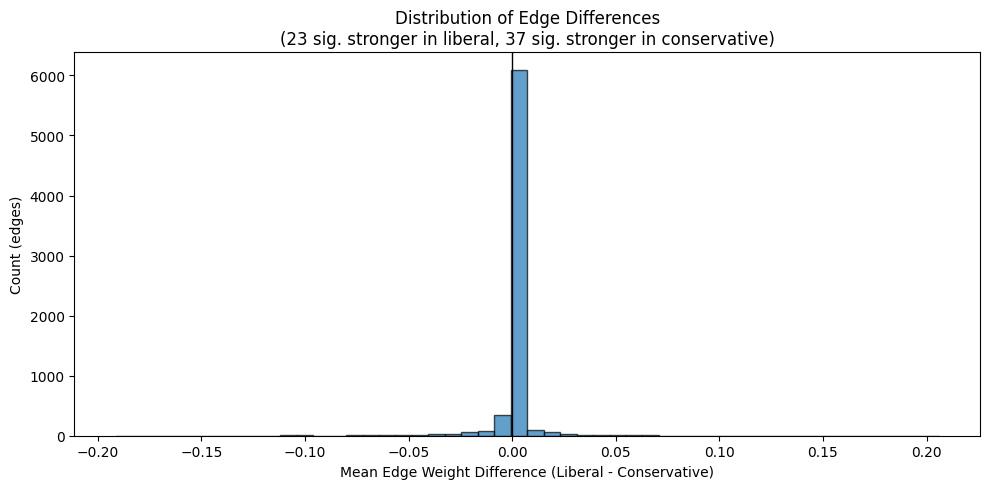

In [13]:
# Visualize the distribution of edge differences
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(mean_diff, bins=50, alpha=0.7, edgecolor='black')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Mean Edge Weight Difference (Liberal - Conservative)')
ax.set_ylabel('Count (edges)')
ax.set_title(f'Distribution of Edge Differences\n'
             f'({len(sig_stronger_lib)} sig. stronger in liberal, '
             f'{len(sig_stronger_con)} sig. stronger in conservative)')
plt.tight_layout()
plt.show()

## 2.4 Density Comparison (Sample-Size Controlled)

With matched sample sizes, re-check the baseline finding that liberals have a denser network.

In [14]:
# Compare networks (matched)
comp_matched = compare_matrices(corr_liberal, corr_con_matched)

# Compare networks (full, for reference)
comp_full = compare_matrices(corr_liberal, corr_con_full)

# Display side by side
metrics = ['num_edges', 'density', 'avg_degree', 'avg_weight_sum',
           'clustering_coefficient', 'calc_num_triangles']

print(f"{'Metric':30s} {'Liberal':>10s} {'Con(matched)':>12s} {'Con(full)':>12s}")
print("-" * 66)

for m in metrics:
    lib_val = comp_matched[m]['matrix1']
    con_m_val = comp_matched[m]['matrix2']
    con_f_val = comp_full[m]['matrix2']
    
    if isinstance(lib_val, float):
        print(f"{m:30s} {lib_val:10.4f} {con_m_val:12.4f} {con_f_val:12.4f}")
    else:
        print(f"{m:30s} {lib_val:10d} {con_m_val:12d} {con_f_val:12d}")

print()
print(f"Euclidean distance (matched): {comp_matched['euclidean_distance']:.4f}")
print(f"Euclidean distance (full):    {comp_full['euclidean_distance']:.4f}")
print(f"Pearson r (matched):          {comp_matched['pearson_correlation']:.4f}")
print(f"Pearson r (full):             {comp_full['pearson_correlation']:.4f}")

Metric                            Liberal Con(matched)    Con(full)
------------------------------------------------------------------
num_edges                             405          356          349
density                            0.0587       0.0516       0.0506
avg_degree                         6.8644       6.0339       5.9153
avg_weight_sum                     0.4189       0.4287       0.4253
clustering_coefficient             0.3689       0.4209       0.4367
calc_num_triangles                    531          411          401

Euclidean distance (matched): 0.8902
Euclidean distance (full):    0.8988
Pearson r (matched):          0.8947
Pearson r (full):             0.8923


In [15]:
# Assessment
lib_edges = comp_matched['num_edges']['matrix1']
con_edges_matched = comp_matched['num_edges']['matrix2']
con_edges_full = comp_full['num_edges']['matrix2']

lib_density = comp_matched['density']['matrix1']
con_density_matched = comp_matched['density']['matrix2']
con_density_full = comp_full['density']['matrix2']

print("=== Density Finding Assessment ===")
print(f"\nBaseline finding: Liberals have {lib_edges} edges vs Conservatives(full) {con_edges_full}")
print(f"After matching:   Liberals have {lib_edges} edges vs Conservatives(matched) {con_edges_matched}")

if lib_edges > con_edges_matched * 1.1:
    print("\n=> Liberal network is STILL denser after sample-size matching.")
    print("   The density difference is NOT a sample size artifact.")
elif con_edges_matched > lib_edges * 1.1:
    print("\n=> Conservative network is DENSER after matching!")
    print("   The baseline finding was likely a sample size artifact.")
else:
    print("\n=> Networks have SIMILAR density after matching.")
    print("   The baseline density difference was largely a sample size artifact.")

=== Density Finding Assessment ===

Baseline finding: Liberals have 405 edges vs Conservatives(full) 349
After matching:   Liberals have 405 edges vs Conservatives(matched) 356

=> Liberal network is STILL denser after sample-size matching.
   The density difference is NOT a sample size artifact.


## 2.5 Community Comparison

Do liberal and conservative networks have similar community structure?

In [16]:
def get_communities(corr_matrix):
    """Build graph and detect communities."""
    mat = corr_matrix.copy()
    np.fill_diagonal(mat.values, 0)
    G = nx.from_pandas_adjacency(mat.abs())
    G.remove_edges_from([(u, v) for u, v, d in G.edges(data=True) if d['weight'] == 0])
    comms = nx.community.louvain_communities(G, weight='weight', seed=42)
    # Build node->community dict
    node_comm = {}
    for i, c in enumerate(comms):
        for node in c:
            node_comm[node] = i
    return comms, node_comm, G

lib_comms, lib_node_comm, G_lib = get_communities(corr_liberal)
con_comms, con_node_comm, G_con = get_communities(corr_con_matched)

print(f"Liberal communities: {len(lib_comms)}")
for i, c in enumerate(sorted(lib_comms, key=len, reverse=True)):
    print(f"  L{i+1} ({len(c)}): {sorted(c)}")

print(f"\nConservative communities: {len(con_comms)}")
for i, c in enumerate(sorted(con_comms, key=len, reverse=True)):
    print(f"  C{i+1} ({len(c)}): {sorted(c)}")

Liberal communities: 26
  L1 (21): ['AFFRMACT', 'CAPPUN', 'COURTS', 'EQWLTH', 'HELPBLK', 'HELPNOT', 'HELPPOOR', 'NATAIDY', 'NATCHLD', 'NATCITYY', 'NATCRIMY', 'NATDRUGY', 'NATEDUCY', 'NATFAREY', 'NATHEALY', 'NATRACEY', 'RACDIF1', 'RACDIF2', 'RACDIF3', 'RACDIF4', 'WRKWAYUP']
  L2 (20): ['COLATH', 'COLCOM', 'COLHOMO', 'COLMIL', 'COLMSLM', 'COLRAC', 'DIDVOTELAST', 'LIBATH', 'LIBCOM', 'LIBHOMO', 'LIBMIL', 'LIBMSLM', 'LIBRAC', 'SEXEDUC', 'SPKATH', 'SPKCOM', 'SPKHOMO', 'SPKMIL', 'SPKMSLM', 'SPKRAC']
  L3 (15): ['CONCLERG', 'FEPOL', 'GRASS', 'HOMOSEX', 'NATARMSY', 'PORNLAW', 'POSTLIFE', 'PRAYER', 'PREMARSX', 'RELIG_Catholic', 'RELIG_None', 'RELIG_Protestant', 'SPANKING', 'TEENSEX', 'XMARSEX']
  L4 (12): ['CONARMY', 'CONBUS', 'CONEDUC', 'CONFED', 'CONFINAN', 'CONJUDGE', 'CONLABOR', 'CONLEGIS', 'CONMEDIC', 'CONPRESS', 'CONSCI', 'CONTV']
  L5 (10): ['ABANY', 'ABDEFECT', 'ABHLTH', 'ABNOMORE', 'ABPOOR', 'ABRAPE', 'ABSINGLE', 'LETDIE1', 'SUICIDE1', 'SUICIDE2']
  L6 (8): ['FAIR', 'HELPFUL', 'HELPOTH'

In [17]:
# Compare community assignments for variables present in both networks
common_nodes = sorted(set(lib_node_comm.keys()) & set(con_node_comm.keys()))

# For each variable, check if it's in the same community (by overlap)
# Since community numbering differs, we need to match by maximum overlap
lib_comms_sorted = sorted(lib_comms, key=len, reverse=True)
con_comms_sorted = sorted(con_comms, key=len, reverse=True)

# Build overlap matrix
overlap_matrix = np.zeros((len(lib_comms_sorted), len(con_comms_sorted)))
for i, lc in enumerate(lib_comms_sorted):
    for j, cc in enumerate(con_comms_sorted):
        overlap_matrix[i, j] = len(lc & cc)

print("Community Overlap Matrix (Lib rows x Con cols):")
print(f"{'':5s}", end='')
for j in range(min(10, len(con_comms_sorted))):
    print(f"C{j+1:2d}", end='  ')
print()

for i in range(min(10, len(lib_comms_sorted))):
    print(f"L{i+1:2d}  ", end='')
    for j in range(min(10, len(con_comms_sorted))):
        val = int(overlap_matrix[i, j])
        if val > 0:
            print(f"{val:3d}", end='  ')
        else:
            print(f"  .", end='  ')
    print()

# Variables that switch communities
print("\n=== Variables That Switch Communities ===")
# Map each liberal community to its best-matching conservative community
lib_to_con_map = {}
for i in range(len(lib_comms_sorted)):
    if overlap_matrix.shape[1] > 0:
        best_j = np.argmax(overlap_matrix[i])
        lib_to_con_map[i] = best_j

switchers = []
for node in common_nodes:
    # Find which liberal community this node is in
    for i, lc in enumerate(lib_comms_sorted):
        if node in lc:
            lib_idx = i
            break
    # Find which conservative community
    for j, cc in enumerate(con_comms_sorted):
        if node in cc:
            con_idx = j
            break
    # Check if it switched
    if lib_idx in lib_to_con_map and lib_to_con_map[lib_idx] != con_idx:
        switchers.append((node, lib_idx, con_idx))

print(f"{len(switchers)} variables switch communities between lib and con networks:")
for node, li, ci in sorted(switchers):
    print(f"  {node}: L{li+1} -> C{ci+1}")

Community Overlap Matrix (Lib rows x Con cols):
     C 1  C 2  C 3  C 4  C 5  C 6  C 7  C 8  C 9  C10  
L 1   18    .    .    .    1    .    .    .    .    .  
L 2    1    1   18    .    .    .    .    .    .    .  
L 3    .    6    1    2    .    4    1    .    .    .  
L 4    .    .    .   12    .    .    .    .    .    .  
L 5    .   10    .    .    .    .    .    .    .    .  
L 6    .    .    .    .    .    .    .    4    3    .  
L 7    4    .    .    .    .    .    .    .    .    .  
L 8    .    .    .    .    5    .    .    .    .    .  
L 9    3    .    .    .    .    .    .    .    .    .  
L10    .    .    .    .    .    .    3    .    .    .  

=== Variables That Switch Communities ===
20 variables switch communities between lib and con networks:
  CONCLERG: L3 -> C4
  COURTS: L1 -> C11
  DIDVOTELAST: L2 -> C1
  FAIR: L6 -> C9
  FEPOL: L3 -> C7
  HELPFUL: L6 -> C9
  NATARMSY: L3 -> C4
  NATCRIMY: L1 -> C16
  NATMASS: L7 -> C14
  NATROAD: L7 -> C15
  POPULAR: L6 -> C13
  POS

C:\Users\timbo\AppData\Local\Temp\ipykernel_27308\3947150481.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', max(n_comms, 1))


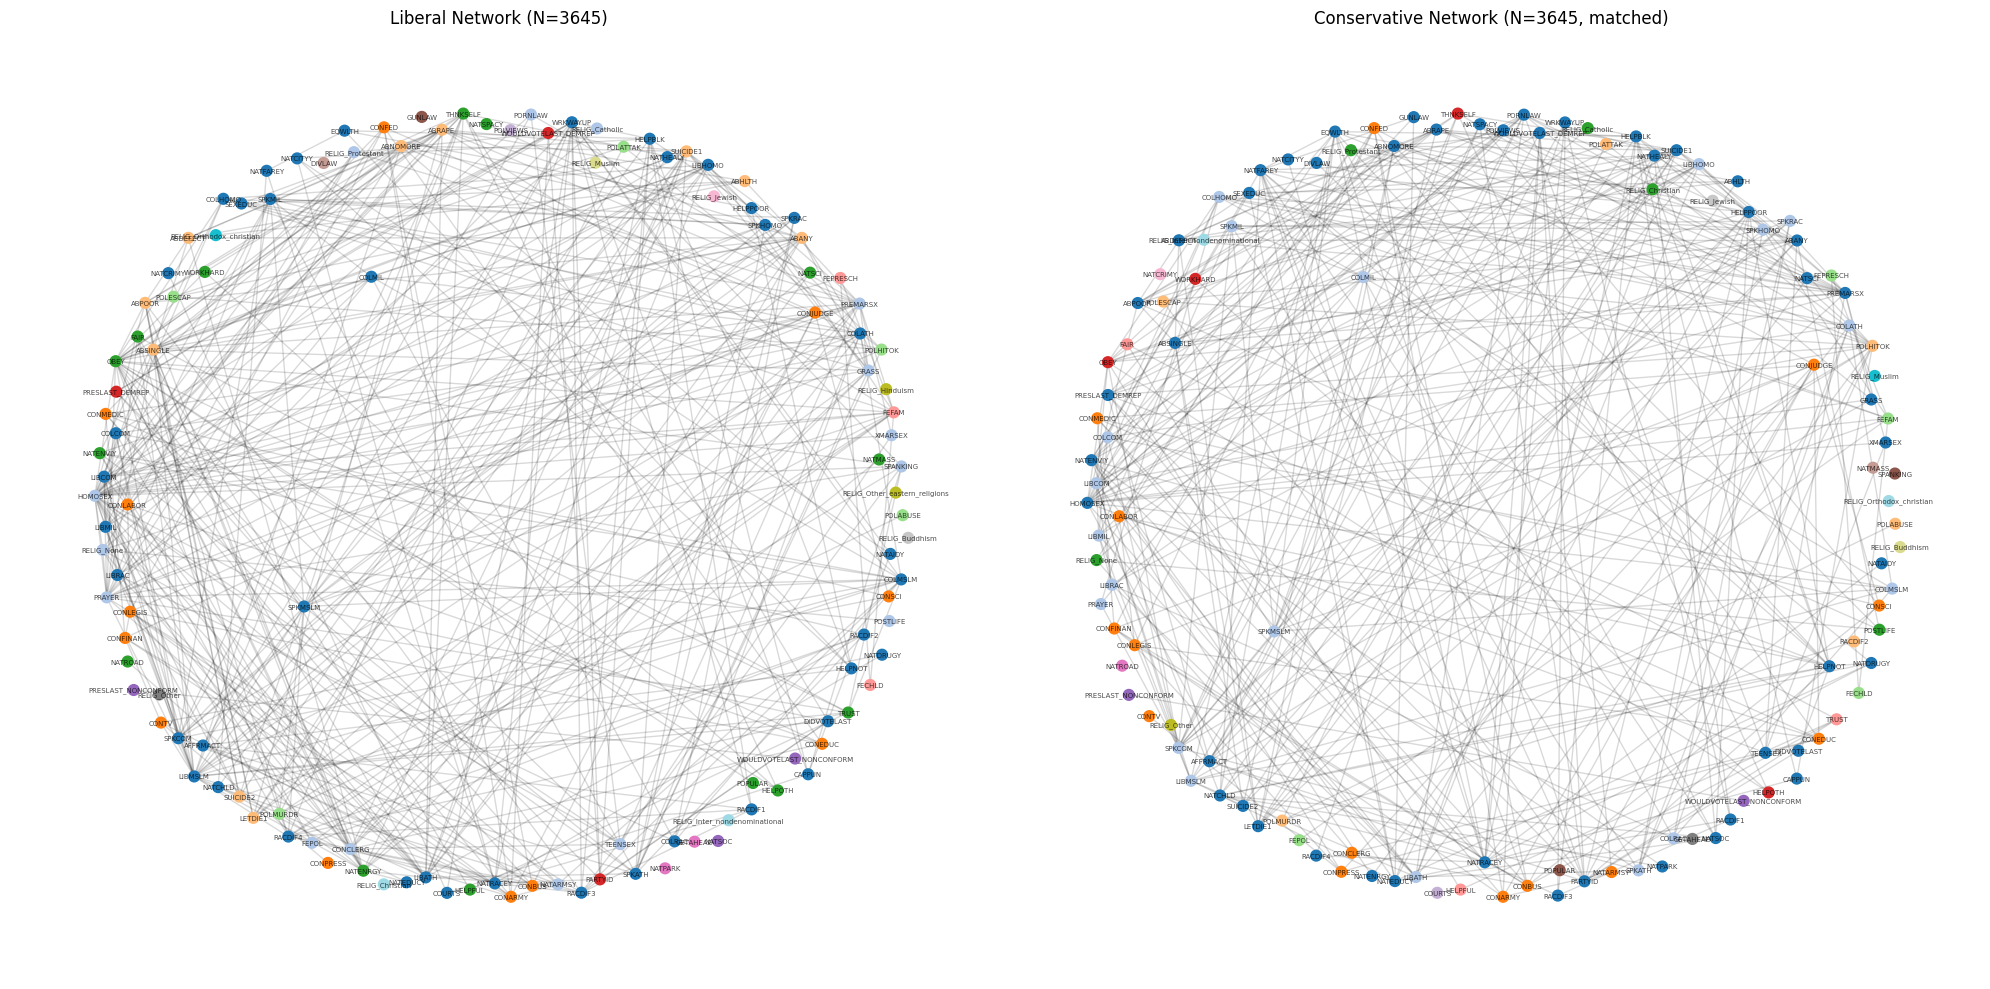

In [18]:
# Side-by-side network visualization
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

for ax, G, comms, title in [
    (axes[0], G_lib, lib_comms, f'Liberal Network (N={N_lib})'),
    (axes[1], G_con, con_comms, f'Conservative Network (N={N_lib}, matched)')
]:
    pos = nx.spring_layout(G, k=2, iterations=100, seed=42, weight='weight')
    sorted_comms = sorted(comms, key=len, reverse=True)
    n_comms = len(sorted_comms)
    cmap = plt.cm.get_cmap('tab20', max(n_comms, 1))
    
    colors = []
    for node in G.nodes():
        for i, c in enumerate(sorted_comms):
            if node in c:
                colors.append(cmap(i))
                break
    
    nx.draw_networkx_edges(G, pos, alpha=0.15, ax=ax)
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=60, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=5, alpha=0.7, ax=ax)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Summary

See `analyses/2026-02_sound-lib-con-comparison.md` for the full writeup.